In [26]:
print(
    "Reviews containing HTML tags:",
    df["Text"].astype(str).str.contains(
        r"<.*?>", regex=True
    ).sum()
)

Reviews containing HTML tags: 7244


In [27]:
print(
    "Empty cleaned reviews:",
    (df["clean_text"].str.strip() == "").sum()
)

Empty cleaned reviews: 0


In [28]:
print(
    "Reviews with less than 10 characters:",
    (df["review_length"] < 10).sum()
)

Reviews with less than 10 characters: 0


In [29]:
print(
    "Reviews with more than 5000 characters:",
    (df["review_length"] > 5000).sum()
)

Reviews with more than 5000 characters: 5


In [30]:
print("========== FINAL EDA SUMMARY ==========")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Reviews:")
print(df["Text"].duplicated().sum())

print("\nAverage Review Length:")
print(round(df["review_length"].mean(), 2))

print("\nShortest Review:")
print(df["review_length"].min())

print("\nLongest Review:")
print(df["review_length"].max())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nTop 10 Words:")
print(word_counts_clean.most_common(10))

print("\nTop 10 Bigrams:")
print(bigram_freq[:10])

print("\nTop 10 Trigrams:")
print(trigram_freq[:10])

========== FINAL EDA SUMMARY ==========
Dataset Shape: (27783, 13)

Missing Values:
2

Duplicate Reviews:
1183

Average Review Length:
409.87

Shortest Review:
29

Longest Review:
9519

Sentiment Distribution:


KeyError: 'sentiment'

In [31]:
# Create sentiment column again

df["sentiment"] = df["Score"].apply(
    lambda x: "Positive" if x >= 4
    else ("Negative" if x <= 2 else "Neutral")
)

print(df["sentiment"].value_counts())

sentiment
Positive    21292
Negative     4151
Neutral      2340
Name: count, dtype: int64


In [32]:
print("========== FINAL EDA SUMMARY ==========")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Reviews:")
print(df["Text"].duplicated().sum())

print("\nAverage Review Length:")
print(round(df["review_length"].mean(), 2))

print("\nShortest Review:")
print(df["review_length"].min())

print("\nLongest Review:")
print(df["review_length"].max())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nTop 10 Words:")
print(word_counts_clean.most_common(10))

print("\nTop 10 Bigrams:")
print(bigram_freq[:10])

print("\nTop 10 Trigrams:")
print(trigram_freq[:10])

========== FINAL EDA SUMMARY ==========
Dataset Shape: (27783, 14)

Missing Values:
2

Duplicate Reviews:
1183

Average Review Length:
409.87

Shortest Review:
29

Longest Review:
9519

Sentiment Distribution:
sentiment
Positive    21292
Negative     4151
Neutral      2340
Name: count, dtype: int64

Top 10 Words:
[('like', 2144), ('coffee', 1754), ('good', 1725), ('one', 1507), ('taste', 1437), ('great', 1395), ('product', 1254), ('would', 1189), ('flavor', 1189), ('food', 1090)]

Top 10 Bigrams:
[('peanut butter', np.int64(146)), ('dog food', np.int64(136)), ('highly recommend', np.int64(131)), ('taste like', np.int64(123)), ('cup coffee', np.int64(114)), ('ive tried', np.int64(112)), ('grocery store', np.int64(102)), ('great product', np.int64(100)), ('gluten free', np.int64(98)), ('dont know', np.int64(89))]

Top 10 Trigrams:
[('blue diamond almonds', np.int64(31)), ('low acid coffee', np.int64(26)), ('local grocery store', np.int64(25)), ('good cup coffee', np.int64(18)), ('puroast

In [ ]:
!wget -O Reviews.csv "https://raw.githubusercontent.com/IBM/skillsbuild-data-analyst/main/amazon_food_reviews/Reviews.csv"


--2026-08-26 14:51:10--  https://raw.githubusercontent.com/IBM/skillsbuild-data-analyst/main/amazon_food_reviews/Reviews.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-26 14:51:10 ERROR 404: Not Found.



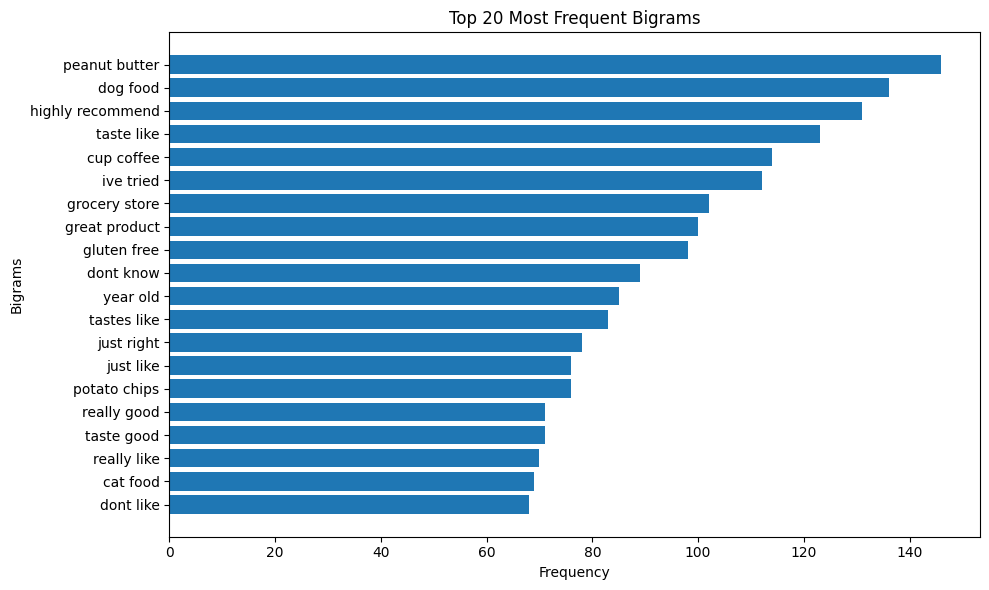

In [ ]:
import matplotlib.pyplot as plt

top_bigrams = bigram_freq[:20]

words = [x[0] for x in top_bigrams]
counts = [x[1] for x in top_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Use the same 5,000-review sample
sample_text = df["clean_text"].sample(
    n=min(5000, len(df)),
    random_state=42
)

vectorizer_tri = CountVectorizer(
    ngram_range=(3, 3),
    stop_words="english",
    max_features=5000
)

X_tri = vectorizer_tri.fit_transform(sample_text)

trigram_counts = X_tri.sum(axis=0).A1
trigrams = vectorizer_tri.get_feature_names_out()

trigram_freq = sorted(
    zip(trigrams, trigram_counts),
    key=lambda x: x[1],
    reverse=True
)

print("Top 20 Trigrams:")

for trigram, count in trigram_freq[:20]:
    print(f"{trigram}: {count}")

Top 20 Trigrams:
blue diamond almonds: 31
low acid coffee: 26
local grocery store: 25
good cup coffee: 18
puroast low acid: 18
regular peanut butter: 17
fructose corn syrup: 15
blue diamond dark: 14
high fructose corn: 14
sea salt vinegar: 14
taste just like: 14
gluten free products: 13
health food store: 13
ounce cans pack: 13
sour cream onion: 13
dry dog food: 12
salt vinegar chips: 12
does taste like: 11
earl grey tea: 11
extra virgin olive: 11


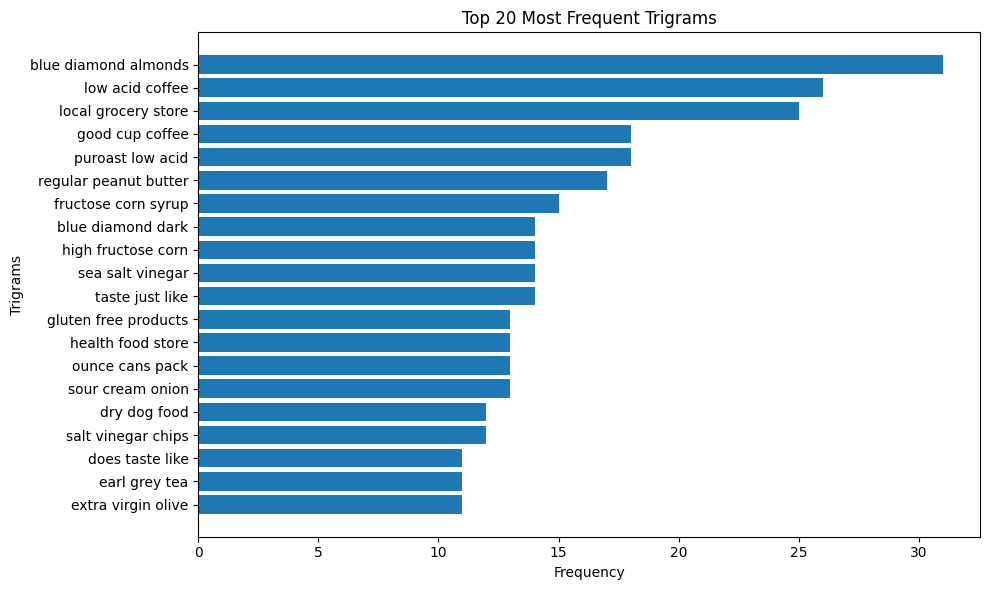

In [ ]:
import matplotlib.pyplot as plt

top_trigrams = trigram_freq[:20]

phrases = [x[0] for x in top_trigrams]
counts = [x[1] for x in top_trigrams]

plt.figure(figsize=(10, 6))
plt.barh(phrases[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

# Use the same 5,000 reviews
sample_text = df["clean_text"].sample(
    n=min(5000, len(df)),
    random_state=42
)

all_words = []

for text in sample_text:
    words = text.split()
    all_words.extend(words)

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

print("Top 20 Most Frequent Words:")
for word, count in top_words:
    print(f"{word}: {count}")

Top 20 Most Frequent Words:
the: 16568
i: 12586
and: 11255
a: 10628
to: 9141
it: 8031
of: 7173
is: 6496
this: 5726
for: 5023
in: 4749
my: 3992
that: 3731
but: 3307
with: 3150
have: 3070
you: 2997
not: 2933
are: 2858
was: 2847


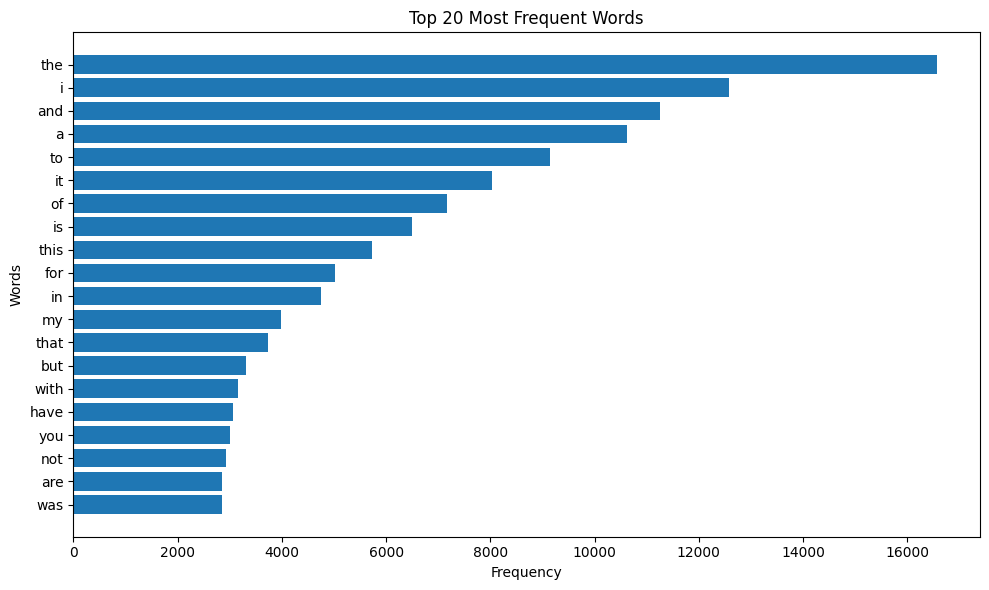

In [ ]:
import matplotlib.pyplot as plt

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [ ]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

sample_text = df["clean_text"].sample(
    n=min(5000, len(df)),
    random_state=42
)

clean_words = []

for text in sample_text:
    words = text.split()

    # Keep only meaningful words
    words = [word for word in words if word not in stop_words]

    clean_words.extend(words)

word_counts_clean = Counter(clean_words)

top_clean_words = word_counts_clean.most_common(20)

print("Top 20 Words After Stopword Removal:")

for word, count in top_clean_words:
    print(f"{word}: {count}")

Top 20 Words After Stopword Removal:
like: 2144
coffee: 1754
good: 1725
one: 1507
taste: 1437
great: 1395
product: 1254
would: 1189
flavor: 1189
food: 1090
love: 1053
get: 948
really: 853
dont: 835
tea: 833
much: 804
time: 762
little: 759
dog: 726
also: 714


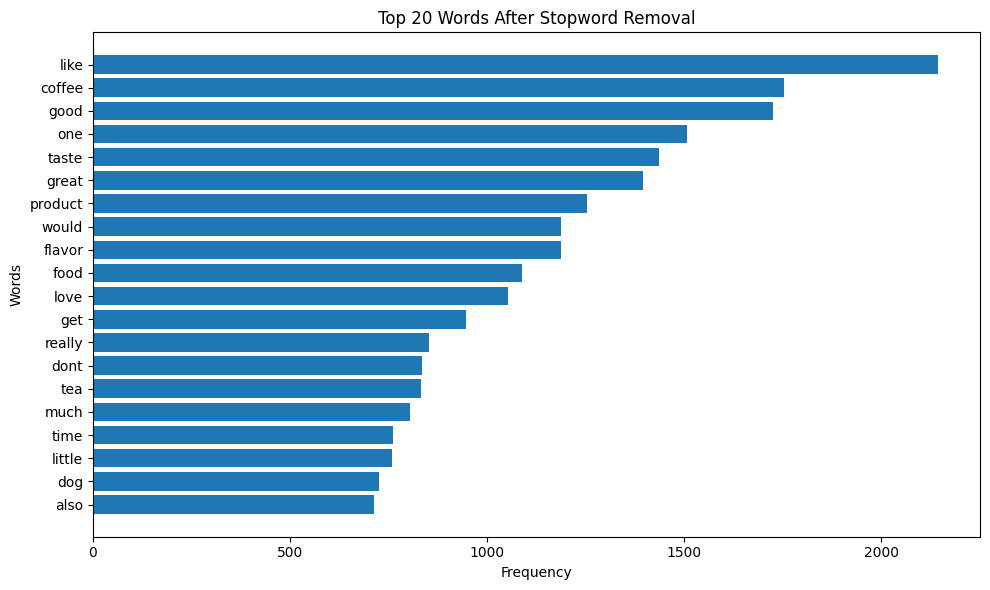

In [ ]:
words = [x[0] for x in top_clean_words]
counts = [x[1] for x in top_clean_words]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Words After Stopword Removal")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [ ]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

display(df[["clean_text", "tokens"]].head())

,clean_text,tokens
0,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ..."
1,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,..."
2,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro..."
3,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr..."
4,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, there, was..."


In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Id                        0
ProductId                 0
UserId                    0
ProfileName               2
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
clean_text                0
tokens                    0
dtype: int64


In [ ]:
# Check duplicate reviews based on the original review text
duplicate_count = df["Text"].duplicated().sum()

print("Number of duplicate reviews:", duplicate_count)

Number of duplicate reviews: 1183


In [ ]:
duplicates = df[df["Text"].duplicated(keep=False)]

print("Duplicate review rows:", len(duplicates))

display(duplicates[["Text"]].head(10))

Duplicate review rows: 2295


,Text
10,I don't know if it's the cactus or the tequila...
29,I don't know if it's the cactus or the tequila...
251,The pork chops from Omaha Steaks were very tas...
267,I used to buy this sugar for years. I do not e...
369,"Green Mountain ""Nantucket Blend"" K-Cups make a..."
422,"Great if you are cutting back on fat, they do ..."
423,I have never met a Kettle brand chip I did not...
424,After buying bags one at a time (at a hefty ma...
425,"I buy mostly for vending, so the size of the b..."
426,Glad to find these in a one ounce size but the...


In [ ]:
df["review_length"] = df["clean_text"].apply(len)

print("Review Length Statistics:")
print(df["review_length"].describe())

Review Length Statistics:
count    27783.000000
mean       409.872224
std        397.665667
min         29.000000
25%        172.000000
50%        290.000000
75%        502.000000
max       9519.000000
Name: review_length, dtype: float64


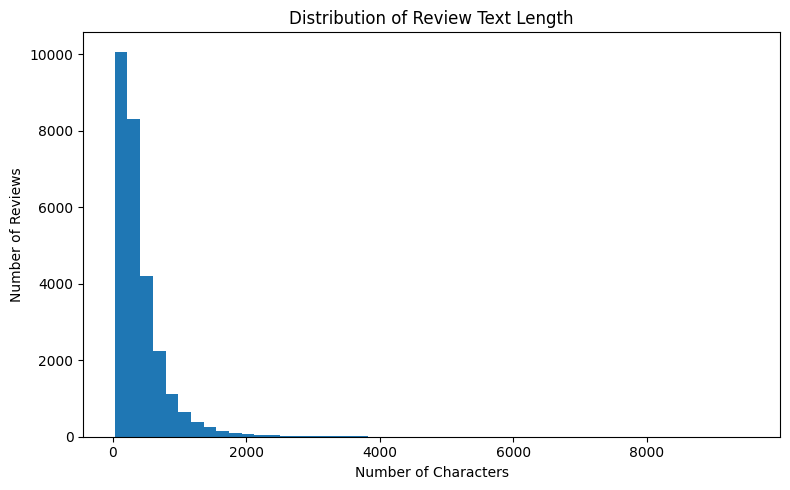

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["review_length"], bins=50)

plt.title("Distribution of Review Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [ ]:
print(
    "Reviews containing URLs:",
    df["Text"].astype(str).str.contains(
        r"http|www", case=False, regex=True
    ).sum()
)

Reviews containing URLs: 611


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print(df.shape)

(40250, 10)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40250 entries, 0 to 40249
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      40250 non-null  int64 
 1   ProductId               40250 non-null  object
 2   UserId                  40250 non-null  object
 3   ProfileName             40247 non-null  object
 4   HelpfulnessNumerator    40250 non-null  int64 
 5   HelpfulnessDenominator  40250 non-null  int64 
 6   Score                   40250 non-null  int64 
 7   Time                    40250 non-null  int64 
 8   Summary                 40249 non-null  object
 9   Text                    40250 non-null  object
dtypes: int64(5), object(5)
memory usage: 3.1+ MB


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,3
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,1
Text,0


In [ ]:
df["Score"].value_counts().sort_index()

,count
Score,
1,3815
2,2274
3,3197
4,5737
5,25227


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
df["review_length"] = df["Text"].apply(len)

df["review_length"].describe()

,review_length
count,40250.000000
mean,429.109714
std,421.437760
min,33.000000
25%,179.000000
50%,301.000000
75%,523.000000
max,10327.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

sentiment
Positive    325713
Negative     61069
Neutral      31476
Name: count, dtype: int64


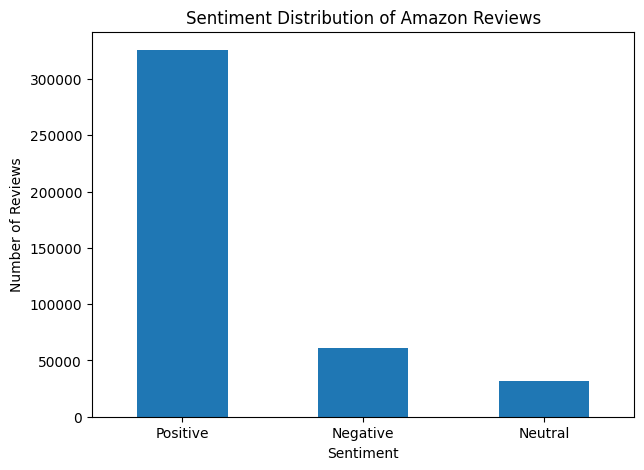

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "/content/Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

# Create sentiment column from Score
df["sentiment"] = df["Score"].apply(
    lambda x: "Positive" if x >= 4 else
              ("Negative" if x <= 2 else "Neutral")
)

# Count sentiments
sentiment_counts = df["sentiment"].value_counts()

# Display counts
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution of Amazon Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

display(df.head())

Shape: (418258, 11)

Columns:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'sentiment'],
      dtype='object')

Data Types:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
sentiment                 object
dtype: object


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive


In [ ]:
missing = df.isnull().sum()
print(missing)

Id                         0
ProductId                  0
UserId                     0
ProfileName               18
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   23
Text                       0
sentiment                  0
dtype: int64


In [ ]:
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


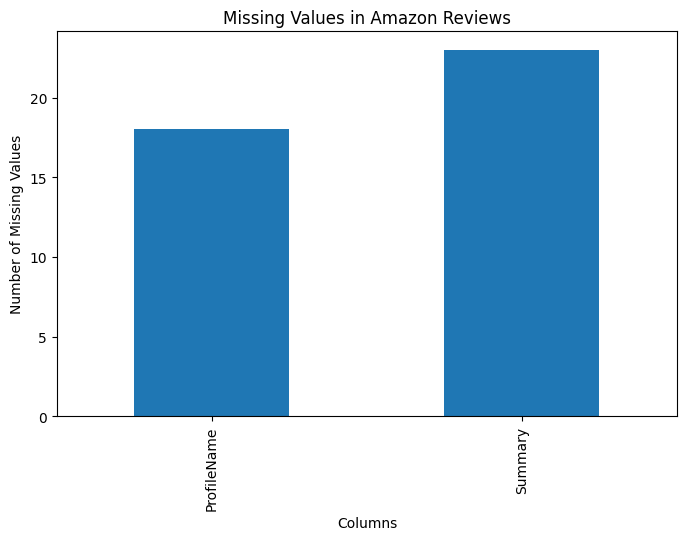

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

missing.plot(kind="bar", figsize=(8,5))
plt.title("Missing Values in Amazon Reviews")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df["text_length"] = df["Text"].astype(str).apply(len)

print(df["text_length"].describe())

count    418258.000000
mean        438.378759
std         445.534546
min          18.000000
25%         180.000000
50%         303.000000
75%         530.000000
max       21409.000000
Name: text_length, dtype: float64


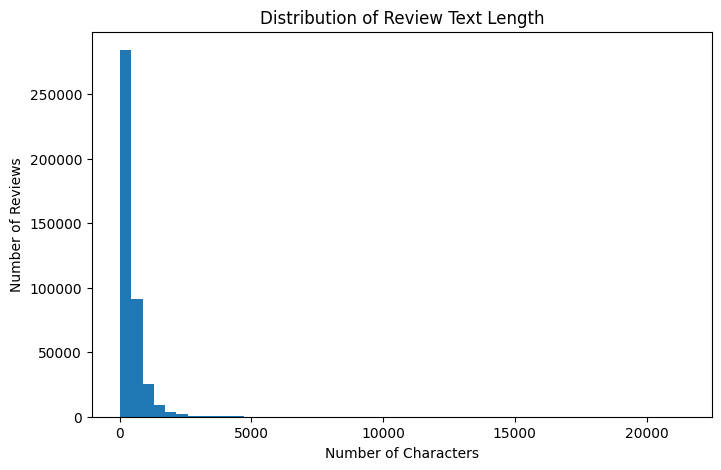

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=50)

plt.title("Distribution of Review Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
print("Empty reviews:",
      df["Text"].isnull().sum())

print("Reviews with URLs:",
      df["Text"].str.contains(r"http|www", case=False, regex=True).sum())

Empty reviews: 0
Reviews with URLs: 8823


In [ ]:
df["clean_text"] = df["Text"].str.lower()

In [ ]:
df["clean_text"] = df["clean_text"].str.replace(
    r"<.*?>", "", regex=True
)

In [ ]:
df["clean_text"] = df["clean_text"].str.replace(
    r"http\S+|www\S+", "", regex=True
)

In [ ]:
df["clean_text"] = df["clean_text"].str.replace(
    r"[^a-zA-Z\s]", "", regex=True
)

In [ ]:
df["clean_text"] = df["clean_text"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

In [ ]:
display(df[["Text", "clean_text"]].head())

,Text,clean_text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


In [ ]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

display(df[["clean_text", "tokens"]].head())

,clean_text,tokens
0,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ..."
1,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,..."
2,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro..."
3,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr..."
4,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, there, was..."


In [ ]:
from collections import Counter

all_words = []

for words in df["tokens_clean"]:
    all_words.extend(words)

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('like', 185578), ('good', 143283), ('one', 125492), ('taste', 122171), ('great', 119350), ('coffee', 116713), ('product', 109068), ('flavor', 104383), ('tea', 95978), ('love', 92660), ('food', 92080), ('would', 91066), ('get', 79449), ('really', 73793), ('dont', 69959), ('much', 67992), ('also', 62030), ('little', 61403), ('use', 61263), ('time', 59709)]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_text"])

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

bigram_freq = sorted(
    zip(bigrams, bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

print(bigram_freq[:20])

[('taste like', np.int64(10783)), ('highly recommend', np.int64(10410)), ('ive tried', np.int64(9713)), ('peanut butter', np.int64(9383)), ('dog food', np.int64(9286)), ('green tea', np.int64(9031)), ('grocery store', np.int64(8923)), ('gluten free', np.int64(8462)), ('tastes like', np.int64(7824)), ('dont know', np.int64(7620)), ('cup coffee', np.int64(6865)), ('cat food', np.int64(6839)), ('really good', np.int64(6651)), ('great product', np.int64(6558)), ('really like', np.int64(6425)), ('just right', np.int64(6413)), ('dont like', np.int64(6218)), ('taste good', np.int64(6071)), ('just like', np.int64(6063)), ('year old', np.int64(5991))]


In [ ]:
ngram_range=(3,3)

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Reviews.csv")

# Create clean_text
df["clean_text"] = df["Text"].astype(str).str.lower()

df["clean_text"] = df["clean_text"].str.replace(
    r"<.*?>", "", regex=True
)

df["clean_text"] = df["clean_text"].str.replace(
    r"http\S+|www\S+", "", regex=True
)

df["clean_text"] = df["clean_text"].str.replace(
    r"[^a-zA-Z\s]", "", regex=True
)

df["clean_text"] = df["clean_text"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

print("Dataset shape:", df.shape)
display(df[["Text", "clean_text"]].head())

Dataset shape: (27783, 11)


,Text,clean_text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Use 5,000 reviews for faster n-gram analysis
sample_text = df["clean_text"].sample(
    n=min(5000, len(df)),
    random_state=42
)

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(sample_text)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

bigram_freq = sorted(
    zip(bigrams, bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

print("Top 20 Bigrams:")

for bigram, count in bigram_freq[:20]:
    print(f"{bigram}: {count}")

Top 20 Bigrams:
peanut butter: 146
dog food: 136
highly recommend: 131
taste like: 123
cup coffee: 114
ive tried: 112
grocery store: 102
great product: 100
gluten free: 98
dont know: 89
year old: 85
tastes like: 83
just right: 78
just like: 76
potato chips: 76
really good: 71
taste good: 71
really like: 70
cat food: 69
dont like: 68


In [ ]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens_clean"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [ ]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True